In [1]:
# ***Prachi - 8025320072***
# ***Assignment 3***

In [2]:
# Part I: Randomized Sales Data Generation (NumPy)

In [4]:
# 1. Initialize Random Seed

import numpy as np

roll_number = 8025320072
valid_seed = roll_number % (2**32)

rng = np.random.default_rng(valid_seed)

sales_data = rng.integers(1000, 5000, size=(12, 4))

print(sales_data)

[[1394 4196 3584 4457]
 [3543 3369 2459 1163]
 [3547 3660 3188 1633]
 [3634 3976 2683 2762]
 [2639 3113 3166 2282]
 [2195 3565 3810 3148]
 [1657 3941 4926 3528]
 [1976 2266 3283 2010]
 [3710 4068 4725 3192]
 [4622 3995 1982 1464]
 [3934 1390 4017 2503]
 [2150 4155 4115 3418]]


In [5]:
# 2. Generate Sales Data (12 × 4)

# Generate random sales data between 1000 and 5000
sales_data = np.random.randint(1000, 5000, size=(12, 4))

sales_data

array([[3281, 1236, 3210, 4537],
       [2568, 2895, 2945, 2969],
       [1872, 4770, 3703, 3466],
       [1642, 1985, 1572, 3685],
       [4814, 4094, 2312, 4506],
       [2559, 2458, 1377, 1905],
       [4987, 3481, 4227, 2025],
       [1503, 4936, 4826, 3551],
       [2945, 3773, 3561, 1257],
       [2594, 3261, 4953, 1766],
       [1652, 4792, 2852, 3783],
       [3472, 2512, 2823, 1538]])

In [6]:
# 3. Convert to DataFrame

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

df = pd.DataFrame(sales_data, columns=columns, index=months)

df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3281,1236,3210,4537
Feb,2568,2895,2945,2969
Mar,1872,4770,3703,3466
Apr,1642,1985,1572,3685
May,4814,4094,2312,4506
Jun,2559,2458,1377,1905
Jul,4987,3481,4227,2025
Aug,1503,4936,4826,3551
Sep,2945,3773,3561,1257
Oct,2594,3261,4953,1766


In [ ]:
# Part II: Data Manipulation and Analysis (Pandas)

In [7]:
# 1. First 5 Rows & Summary Statistics

df.head()
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,2824.083333,3349.416667,3196.750000,2915.666667
std,1163.567278,1183.440935,1137.997933,1167.631272
min,1503.000000,1236.000000,1377.000000,1257.000000
25%,1817.000000,2498.500000,2695.250000,1870.250000
50%,2581.000000,3371.000000,3077.500000,3217.500000
75%,3328.750000,4263.000000,3834.000000,3709.500000
max,4987.000000,4936.000000,4953.000000,4537.000000


In [8]:
# 2. Total Sales per Category & per Month

# Total per category
total_per_category = df.sum()
print("Total Sales per Category:\n", total_per_category)

# Total per month
total_per_month = df.sum(axis=1)
print("\nTotal Sales per Month:\n", total_per_month)

Total Sales per Category:
 Electronics       33889
Clothing          40193
Home & Kitchen    38361
Sports            34988
dtype: int64

Total Sales per Month:
 Jan    12264
Feb    11377
Mar    13811
Apr     8884
May    15726
Jun     8299
Jul    14720
Aug    14816
Sep    11536
Oct    12574
Nov    13079
Dec    10345
dtype: int64


In [9]:
# 3. Average Sales Growth Between Consecutive Months

growth = df.pct_change()

avg_growth = growth.mean() * 100
print("Average Growth Rate (%):\n", avg_growth)

Average Growth Rate (%):
 Electronics       24.373931
Clothing          22.958697
Home & Kitchen    14.286604
Sports             5.951981
dtype: float64


In [12]:
# 4. Add Total Sales & Growth Rate Columns

df["Total Sales"] = df.sum(axis=1)

df["Growth Rate"] = df["Total Sales"].pct_change() * 100

df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3281,1236,3210,4537,36792.000000,NaN
Feb,2568,2895,2945,2969,34116.505412,-7.271947
Mar,1872,4770,3703,3466,41475.920733,21.571422
Apr,1642,1985,1572,3685,26580.472239,-35.913485
May,4814,4094,2312,4506,47332.820160,78.073661
Jun,2559,2458,1377,1905,24802.266261,-47.600278
Jul,4987,3481,4227,2025,44315.715137,78.676072
Aug,1503,4936,4826,3551,44449.042728,0.300858
Sep,2945,3773,3561,1257,34563.647120,-22.239839
Oct,2594,3261,4953,1766,37740.139563,9.190270


In [13]:
# 5. Apply Randomized Discount

if roll_number % 2 == 0:
    df["Electronics"] = df["Electronics"] * 0.9
    print("10% Discount Applied to Electronics")
else:
    df["Clothing"] = df["Clothing"] * 0.85
    print("15% Discount Applied to Clothing")

df.head()

10% Discount Applied to Electronics


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,2952.9,1236,3210,4537,36792.000000,NaN
Feb,2311.2,2895,2945,2969,34116.505412,-7.271947
Mar,1684.8,4770,3703,3466,41475.920733,21.571422
Apr,1477.8,1985,1572,3685,26580.472239,-35.913485
May,4332.6,4094,2312,4506,47332.820160,78.073661


In [ ]:
# Part III: Visualizations (Matplotlib & Seaborn)

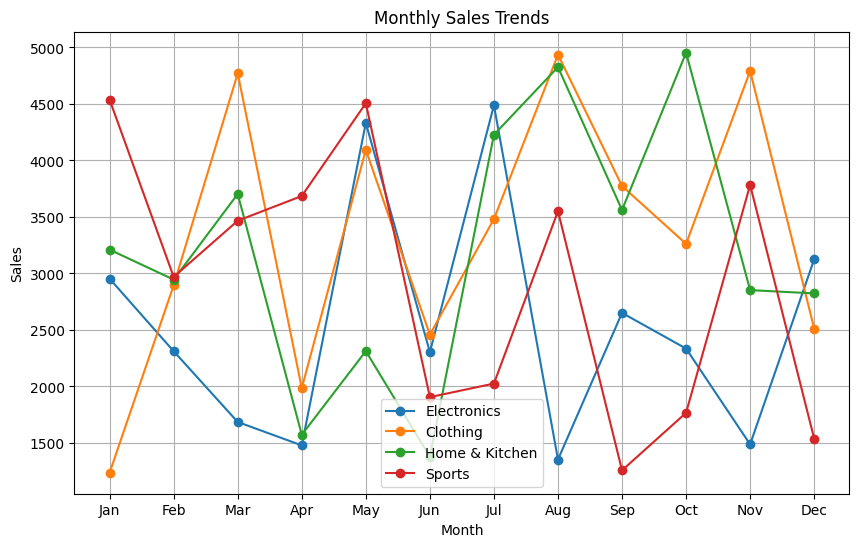

In [14]:
# 1. Monthly Sales Trends (Line Plot)

plt.figure(figsize=(10,6))

for column in columns:
    plt.plot(df.index, df[column], marker='o', label=column)

plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

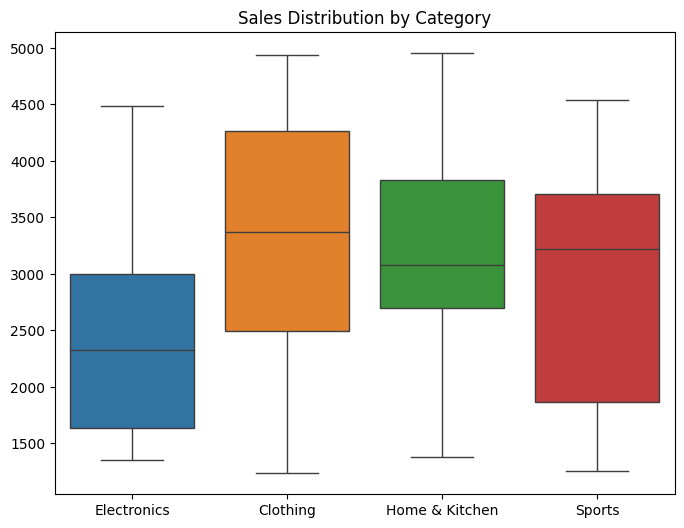

In [15]:
# 2. Box Plot – Sales Distribution

plt.figure(figsize=(8,6))
sns.boxplot(data=df[columns])
plt.title("Sales Distribution by Category")
plt.show()

In [ ]:
# Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])

In [17]:
# i) Element-wise Absolute Value

array = np.array([[1, -2, 3],[-4, 5, -6]])
np.abs(array)

array([[1, 2, 3],
       [4, 5, 6]])

In [18]:
# ii) Percentiles

# Flattened
np.percentile(array.flatten(), [25, 50, 75])

# Column-wise
np.percentile(array, [25, 50, 75], axis=0)

# Row-wise
np.percentile(array, [25, 50, 75], axis=1)

array([[-0.5, -5. ],
       [ 1. , -4. ],
       [ 2. ,  0.5]])

In [19]:
# iii) Mean, Median, Std

# Flattened
print("Mean:", np.mean(array))
print("Median:", np.median(array))
print("Std:", np.std(array))

# Column-wise
print("Column Mean:", np.mean(array, axis=0))
print("Column Median:", np.median(array, axis=0))
print("Column Std:", np.std(array, axis=0))

# Row-wise
print("Row Mean:", np.mean(array, axis=1))
print("Row Median:", np.median(array, axis=1))
print("Row Std:", np.std(array, axis=1))

Mean: -0.5
Median: -0.5
Std: 3.8622100754188224
Column Mean: [-1.5  1.5 -1.5]
Column Median: [-1.5  1.5 -1.5]
Column Std: [2.5 3.5 4.5]
Row Mean: [ 0.66666667 -1.66666667]
Row Median: [ 1. -4.]
Row Std: [2.05480467 4.78423336]


In [20]:
# Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).

a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Floor:", np.floor(a))
print("Ceiling:", np.ceil(a))
print("Truncated:", np.trunc(a))
print("Rounded:", np.round(a))

Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceiling: [-1. -1. -0.  1.  2.  2.  3.]
Truncated: [-1. -1. -0.  0.  1.  1.  3.]
Rounded: [-2. -2. -0.  0.  2.  2.  3.]


In [21]:
# Q.4 WAP to swap two elements in a list in Python Using a Temporary Variable.

lst = [10, 20, 30, 40]

pos1 = 1
pos2 = 3

temp = lst[pos1]
lst[pos1] = lst[pos2]
lst[pos2] = temp

print("Swapped List:", lst)

Swapped List: [10, 40, 30, 20]


In [22]:
# Q.5 Write a Python program to swap two elements in a set by converting it to a list first.

s = {1, 2, 3, 4}

# Convert to list
lst = list(s)

pos1 = 0
pos2 = 2

# Swap
lst[pos1], lst[pos2] = lst[pos2], lst[pos1]

# Convert back to set
s = set(lst)

print("Swapped Set:", s)

Swapped Set: {1, 2, 3, 4}
